<a href="https://colab.research.google.com/github/Namish-07/FDS/blob/main/FDS_lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# TITANIC DATASET - DATA WRANGLING
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
# Basic information
print("----- DATASET INFORMATION -----")
df.info()

print("\n----- SHAPE -----")
print(df.shape)

print("\n----- COLUMN NAMES -----")
print(df.columns.tolist())

print("\n----- DATA TYPES -----")
print(df.dtypes)

print("\n----- STATISTICAL SUMMARY -----")
display(df.describe(include="all"))

----- DATASET INFORMATION -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

----- SHAPE -----
(891, 15)

----- COLUMN NAME

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("----- MISSING VALUES BEFORE CLEANING -----")

missing = df.isnull().sum()

print(missing)

print("\nMissing percentage:")
print((df.isnull().sum() / len(df)) * 100)

----- MISSING VALUES BEFORE CLEANING -----
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Missing percentage:
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


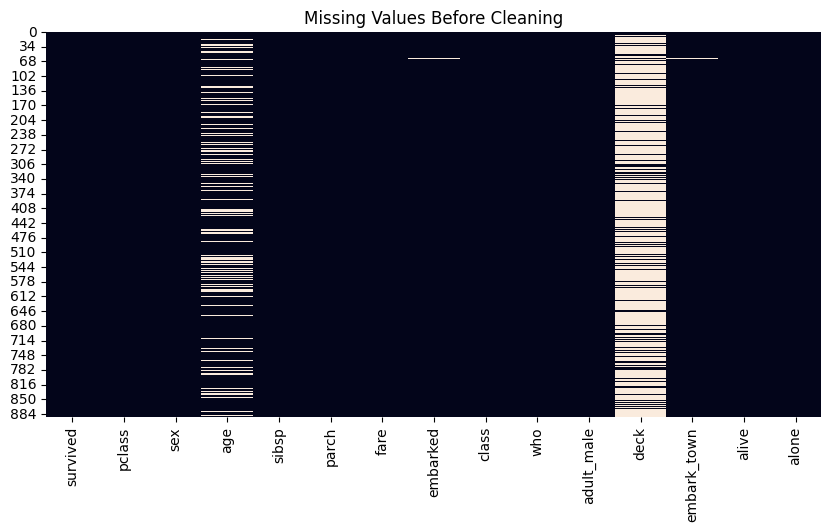

In [4]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Before Cleaning")
plt.show()

In [5]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [6]:
# Age: fill missing values using median
age_median = df["age"].median()
df["age"] = df["age"].fillna(age_median)

# Embarked: fill missing values using mode
embarked_mode = df["embarked"].mode()[0]
df["embarked"] = df["embarked"].fillna(embarked_mode)

# Drop columns with excessive missing values / redundancy
df.drop(columns=["deck", "embark_town"], inplace=True)

In [7]:
print("----- MISSING VALUES AFTER IMPUTATION -----")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

----- MISSING VALUES AFTER IMPUTATION -----
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

Total missing values: 0


In [8]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
116


In [9]:
duplicates_before = df.duplicated().sum()

df.drop_duplicates(inplace=True)

duplicates_after = df.duplicated().sum()

print("Duplicates before:", duplicates_before)
print("Duplicates after:", duplicates_after)

Duplicates before: 116
Duplicates after: 0


In [10]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


In [11]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].unique())


 sex
['male' 'female']

 embarked
['S' 'C' 'Q']

 who
['man' 'woman' 'child']

 alive
['no' 'yes']


In [12]:
print("Sex values:")
print(df["sex"].unique())

print("\nEmbarked values:")
print(df["embarked"].unique())

print("\nWho values:")
print(df["who"].unique())

print("\nClass values:")
print(df["class"].unique())

Sex values:
['male' 'female']

Embarked values:
['S' 'C' 'Q']

Who values:
['man' 'woman' 'child']

Class values:
['Third', 'First', 'Second']
Categories (3, object): ['First', 'Second', 'Third']


In [13]:
df["sex"] = df["sex"].str.lower()
df["embarked"] = df["embarked"].str.lower()
df["who"] = df["who"].str.lower()

In [14]:
print(df["sex"].unique())
print(df["embarked"].unique())
print(df["who"].unique())

['male' 'female']
['s' 'c' 'q']
['man' 'woman' 'child']


In [15]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns.tolist())

display(df[numerical_columns].describe())

Numerical columns:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']


,survived,pclass,age,sibsp,parch,fare
count,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000
mean,0.412903,2.246452,29.581187,0.529032,0.420645,34.878403
std,0.492674,0.853574,13.766359,0.990326,0.840565,52.408474
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,34.197900
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    print(f"\nColumn: {column}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Number of outliers:", len(outliers))

    return outliers

In [17]:
age_outliers = detect_outliers_iqr(df, "age")
fare_outliers = detect_outliers_iqr(df, "fare")


Column: age
Q1: 21.0
Q3: 36.0
IQR: 15.0
Lower bound: -1.5
Upper bound: 58.5
Number of outliers: 27

Column: fare
Q1: 8.05
Q3: 34.197900000000004
IQR: 26.147900000000003
Lower bound: -31.171850000000003
Upper bound: 73.41975000000001
Number of outliers: 102


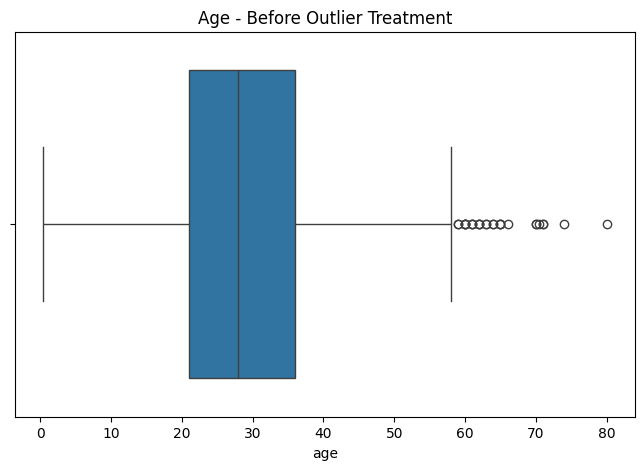

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["age"])
plt.title("Age - Before Outlier Treatment")
plt.show()

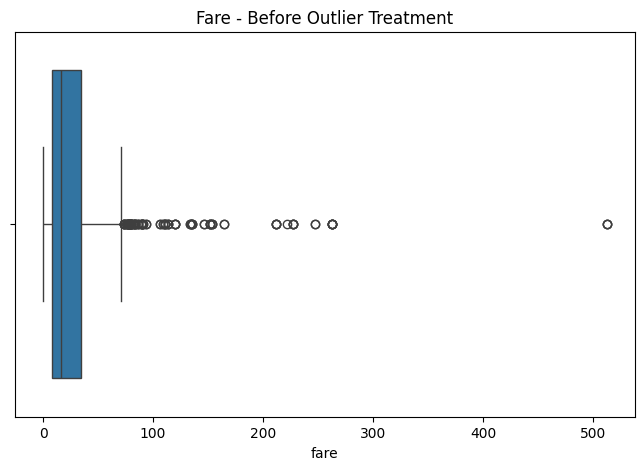

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["fare"])
plt.title("Fare - Before Outlier Treatment")
plt.show()

In [20]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["fare"] = df["fare"].clip(
    lower_bound,
    upper_bound
)

In [21]:
print("Fare minimum after capping:", df["fare"].min())
print("Fare maximum after capping:", df["fare"].max())

Fare minimum after capping: 0.0
Fare maximum after capping: 73.41975000000001


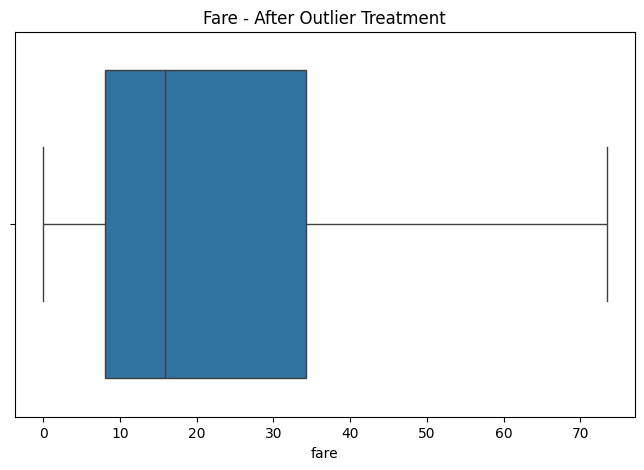

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["fare"])
plt.title("Fare - After Outlier Treatment")
plt.show()

In [24]:
print("----- DATA TYPES BEFORE CONVERSION -----")
print(df.dtypes)

----- DATA TYPES BEFORE CONVERSION -----
survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class         category
who             object
adult_male        bool
alive           object
alone             bool
dtype: object


In [25]:
categorical_columns = [
    "sex",
    "embarked",
    "who",
    "class",
    "deck"
]

# Only convert columns that still exist
categorical_columns = [
    col for col in categorical_columns
    if col in df.columns
]

for col in categorical_columns:
    df[col] = df[col].astype("category")

In [26]:
print("----- DATA TYPES AFTER CONVERSION -----")
print(df.dtypes)

----- DATA TYPES AFTER CONVERSION -----
survived         int64
pclass           int64
sex           category
age            float64
sibsp            int64
parch            int64
fare           float64
embarked      category
class         category
who           category
adult_male        bool
alive           object
alone             bool
dtype: object


In [27]:
df_encoded = pd.get_dummies(
    df,
    columns=["sex", "embarked", "who", "class"],
    drop_first=True,
    dtype=int
)

print("Encoded dataset:")
display(df_encoded.head())

Encoded dataset:


,survived,pclass,age,sibsp,parch,fare,adult_male,alive,alone,sex_male,embarked_q,embarked_s,who_man,who_woman,class_Second,class_Third
0,0,3,22.0,1,0,7.2500,True,no,False,1,0,1,1,0,0,1
1,1,1,38.0,1,0,71.2833,False,yes,False,0,0,0,0,1,0,0
2,1,3,26.0,0,0,7.9250,False,yes,True,0,0,1,0,1,0,1
3,1,1,35.0,1,0,53.1000,False,yes,False,0,0,1,0,1,0,0
4,0,3,35.0,0,0,8.0500,True,no,True,1,0,1,1,0,0,1


In [28]:
print("Remaining categorical columns:")

print(
    df_encoded.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
)

Remaining categorical columns:
['alive']


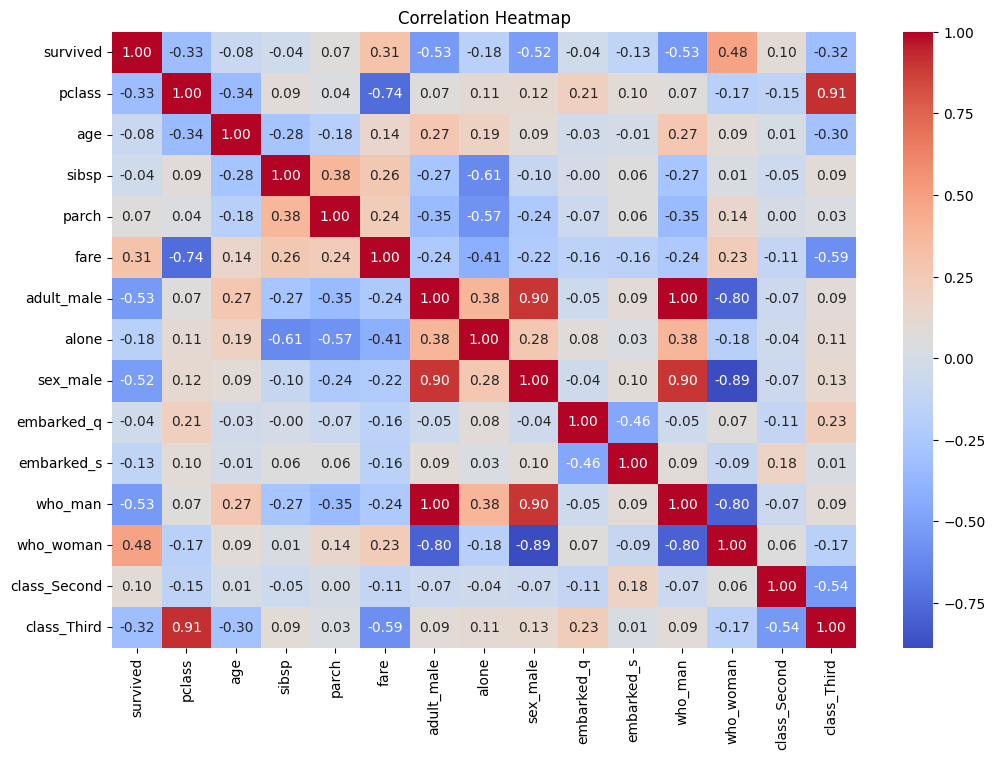

In [29]:
plt.figure(figsize=(12, 8))

correlation = df_encoded.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [30]:
print("Age < 0:", (df["age"] < 0).sum())
print("Age > 100:", (df["age"] > 100).sum())

Age < 0: 0
Age > 100: 0


In [31]:
print("Fare < 0:", (df["fare"] < 0).sum())

Fare < 0: 0


In [32]:
print("Passenger classes:")
print(df["pclass"].unique())

Passenger classes:
[3 1 2]


In [33]:
print("----- FINAL DATA QUALITY CHECK -----")

print("\nMissing values:")
print(df_encoded.isnull().sum())

print("\nDuplicate rows:")
print(df_encoded.duplicated().sum())

print("\nData shape:")
print(df_encoded.shape)

print("\nData types:")
print(df_encoded.dtypes)

----- FINAL DATA QUALITY CHECK -----

Missing values:
survived        0
pclass          0
age             0
sibsp           0
parch           0
fare            0
adult_male      0
alive           0
alone           0
sex_male        0
embarked_q      0
embarked_s      0
who_man         0
who_woman       0
class_Second    0
class_Third     0
dtype: int64

Duplicate rows:
6

Data shape:
(775, 16)

Data types:
survived          int64
pclass            int64
age             float64
sibsp             int64
parch             int64
fare            float64
adult_male         bool
alive            object
alone              bool
sex_male          int64
embarked_q        int64
embarked_s        int64
who_man           int64
who_woman         int64
class_Second      int64
class_Third       int64
dtype: object


In [34]:
scaler = StandardScaler()

scale_columns = ["age", "fare"]

df_encoded[scale_columns] = scaler.fit_transform(
    df_encoded[scale_columns]
)

In [35]:
print("Mean after scaling:")
print(df_encoded[scale_columns].mean())

print("\nStandard deviation after scaling:")
print(df_encoded[scale_columns].std())

Mean after scaling:
age     2.521281e-16
fare   -3.896525e-17
dtype: float64

Standard deviation after scaling:
age     1.000646
fare    1.000646
dtype: float64


In [36]:
print("======================================")
print("FINAL DATASET VERIFICATION")
print("======================================")

print("\n1. Dataset Shape:")
print(df_encoded.shape)

print("\n2. Missing Values:")
print(df_encoded.isnull().sum().sum())

print("\n3. Duplicate Rows:")
print(df_encoded.duplicated().sum())

print("\n4. Data Types:")
print(df_encoded.dtypes)

print("\n5. First 5 Rows:")
display(df_encoded.head())

print("\n6. Statistical Summary:")
display(df_encoded.describe())

FINAL DATASET VERIFICATION

1. Dataset Shape:
(775, 16)

2. Missing Values:
0

3. Duplicate Rows:
6

4. Data Types:
survived          int64
pclass            int64
age             float64
sibsp             int64
parch             int64
fare            float64
adult_male         bool
alive            object
alone              bool
sex_male          int64
embarked_q        int64
embarked_s        int64
who_man           int64
who_woman         int64
class_Second      int64
class_Third       int64
dtype: object

5. First 5 Rows:


,survived,pclass,age,sibsp,parch,fare,adult_male,alive,alone,sex_male,embarked_q,embarked_s,who_man,who_woman,class_Second,class_Third
0,0,3,-0.551060,1,0,-0.846218,True,no,False,1,0,1,1,0,0,1
1,1,1,0.611945,1,0,1.955092,False,yes,False,0,0,0,0,1,0,0
2,1,3,-0.260308,0,0,-0.816688,False,yes,True,0,0,1,0,1,0,1
3,1,1,0.393881,1,0,1.159615,False,yes,False,0,0,1,0,1,0,0
4,0,3,0.393881,0,0,-0.811220,True,no,True,1,0,1,1,0,0,1



6. Statistical Summary:


,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_q,embarked_s,who_man,who_woman,class_Second,class_Third
count,775.000000,775.000000,7.750000e+02,775.000000,775.000000,7.750000e+02,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000
mean,0.412903,2.246452,2.521281e-16,0.529032,0.420645,-3.896525e-17,0.623226,0.074839,0.725161,0.571613,0.322581,0.211613,0.517419
std,0.492674,0.853574,1.000646e+00,0.990326,0.840565,1.000646e+00,0.484890,0.263301,0.446721,0.495165,0.467766,0.408716,0.500019
min,0.000000,1.000000,-2.119661e+00,0.000000,0.000000,-1.163389e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,-6.237473e-01,0.000000,0.000000,-8.112198e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,3.000000,-1.149330e-01,0.000000,0.000000,-4.678003e-01,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000
75%,1.000000,3.000000,4.665691e-01,1.000000,1.000000,3.326910e-01,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,1.000000,3.000000,3.664831e+00,8.000000,6.000000,2.048557e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [37]:
# Check duplicates before removal
print("Duplicates before:", df_encoded.duplicated().sum())

# Remove duplicate rows
df_encoded = df_encoded.drop_duplicates().reset_index(drop=True)

# Verify again
print("Duplicates after:", df_encoded.duplicated().sum())

print("Final shape:", df_encoded.shape)

Duplicates before: 6
Duplicates after: 0
Final shape: (769, 16)


In [38]:
print("======================================")
print("FINAL DATASET VERIFICATION")
print("======================================")

print("\n1. Dataset Shape:")
print(df_encoded.shape)

print("\n2. Missing Values:")
print(df_encoded.isnull().sum().sum())

print("\n3. Duplicate Rows:")
print(df_encoded.duplicated().sum())

print("\n4. Data Types:")
print(df_encoded.dtypes)

print("\n5. First 5 Rows:")
display(df_encoded.head())

print("\n6. Statistical Summary:")
display(df_encoded.describe())

FINAL DATASET VERIFICATION

1. Dataset Shape:
(769, 16)

2. Missing Values:
0

3. Duplicate Rows:
0

4. Data Types:
survived          int64
pclass            int64
age             float64
sibsp             int64
parch             int64
fare            float64
adult_male         bool
alive            object
alone              bool
sex_male          int64
embarked_q        int64
embarked_s        int64
who_man           int64
who_woman         int64
class_Second      int64
class_Third       int64
dtype: object

5. First 5 Rows:


,survived,pclass,age,sibsp,parch,fare,adult_male,alive,alone,sex_male,embarked_q,embarked_s,who_man,who_woman,class_Second,class_Third
0,0,3,-0.551060,1,0,-0.846218,True,no,False,1,0,1,1,0,0,1
1,1,1,0.611945,1,0,1.955092,False,yes,False,0,0,0,0,1,0,0
2,1,3,-0.260308,0,0,-0.816688,False,yes,True,0,0,1,0,1,0,1
3,1,1,0.393881,1,0,1.159615,False,yes,False,0,0,1,0,1,0,0
4,0,3,0.393881,0,0,-0.811220,True,no,True,1,0,1,1,0,0,1



6. Statistical Summary:


,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_q,embarked_s,who_man,who_woman,class_Second,class_Third
count,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000
mean,0.408322,2.256177,-0.000994,0.527958,0.422627,-0.015984,0.628088,0.075423,0.728218,0.576073,0.317295,0.213264,0.521456
std,0.491843,0.849734,1.004116,0.993238,0.842898,0.987964,0.483630,0.264244,0.445167,0.494501,0.465726,0.409879,0.499865
min,0.000000,1.000000,-2.119661,0.000000,0.000000,-1.163389,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,-0.623747,0.000000,0.000000,-0.811220,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,3.000000,-0.114933,0.000000,0.000000,-0.469988,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000
75%,1.000000,3.000000,0.466569,1.000000,1.000000,0.280286,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,1.000000,3.000000,3.664831,8.000000,6.000000,2.048557,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
